# European Drug Development

### Load data
Import libraries, read the CSV, and preview the first rows.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Medicines_output_european_public_assessment_reports.csv", skiprows=8, header=0)
df.head()




,Category,Medicine name,Therapeutic area,International non-proprietary name (INN) / common name,Active substance,Product number,Patient safety,Authorisation status,ATC code,Additional monitoring,...,Vet pharmacotherapeutic group,Date of opinion,Decision date,Revision number,Condition / indication,Species,ATCvet code,First published,Revision date,URL
0,Human,Adcetris,"Lymphoma, Non-Hodgkin; Hodgkin Disease",brentuximab vedotin,Brentuximab vedotin,EMEA/H/C/002455,no,Authorised,L01XC12,no,...,NaN,19/07/2012,17/11/2022,34.0,Hodgkin lymphomaAdcetris is indicated for adul...,NaN,NaN,25/07/2018,13/03/2023,https://www.ema.europa.eu/en/medicines/human/E...
1,Human,Nityr,Tyrosinemias,nitisinone,nitisinone,EMEA/H/C/004582,no,Authorised,A16AX04,no,...,NaN,31/05/2018,10/03/2023,4.0,Treatment of adult and paediatric patients wit...,NaN,NaN,26/07/2018,10/03/2023,https://www.ema.europa.eu/en/medicines/human/E...
2,Human,Ebvallo,Lymphoproliferative Disorders,tabelecleucel,Tabelecleucel,EMEA/H/C/004577,no,Authorised,NaN,yes,...,NaN,13/10/2022,9/03/2023,2.0,Ebvallo is indicated as monotherapy for treatm...,NaN,NaN,12/10/2022,10/03/2023,https://www.ema.europa.eu/en/medicines/human/E...
3,Human,Ronapreve,COVID-19 virus infection,"casirivimab, imdevimab","casirivimab, imdevimab",EMEA/H/C/005814,no,Authorised,J06BD,yes,...,NaN,11/11/2021,24/02/2023,3.0,Ronapreve is indicated for:Treatment of COVID-...,NaN,NaN,12/11/2021,10/03/2023,https://www.ema.europa.eu/en/medicines/human/E...
4,Human,Cosentyx,"Arthritis, Psoriatic; Psoriasis; Spondylitis...",secukinumab,Secukinumab,EMEA/H/C/003729,no,Authorised,L04AC10,no,...,NaN,20/11/2014,26/01/2023,30.0,Plaque psoriasisCosentyx is indicated for the ...,NaN,NaN,7/06/2018,9/03/2023,https://www.ema.europa.eu/en/medicines/human/E...


### Dataset schema
Inspect column types and non-null counts.

In [2]:
df.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1988 entries, 0 to 1987
Data columns (total 30 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   Category                                                1988 non-null   object 
 1   Medicine name                                           1988 non-null   object 
 2   Therapeutic area                                        1703 non-null   object 
 3   International non-proprietary name (INN) / common name  1984 non-null   object 
 4   Active substance                                        1987 non-null   object 
 5   Product number                                          1988 non-null   object 
 6   Patient safety                                          1988 non-null   object 
 7   Authorisation status                                    1987 non-null   object 
 8   ATC code                              

### Numeric summary
Generate descriptive statistics for numeric columns.

In [3]:
df.describe()

,Revision number
count,1892.000000
mean,13.527484
std,11.647056
min,0.000000
25%,4.750000
50%,11.000000
75%,19.000000
max,89.000000


## **Q1: Which medicines are most similar by indication?**

### Parse date columns
Convert date fields to datetime.

In [4]:

date_cols = [
    "Marketing authorisation date",
    "Date of refusal of marketing authorisation",
    "Date of opinion",
    "Decision date",
    "First published",
    "Revision date"
]

for c in date_cols:
    if c in df.columns:
        df[c] = pd.to_datetime(df[c], errors="coerce", dayfirst=True)

### Normalize yes/no flags
Convert yes/no columns to numeric indicators.

In [5]:
yn_cols = [
    "Patient safety", "Additional monitoring", "Generic", "Biosimilar",
    "Conditional approval", "Exceptional circumstances",
    "Accelerated assessment", "Orphan medicine"
]

for c in yn_cols:
    if c in df.columns:
        df[c] = (df[c].astype(str).str.strip().str.lower()
                   .replace({"yes": 1, "no": 0, "nan": np.nan, "": np.nan}))

/var/folders/jq/pnbcz95j78957hwkvq1nhmpr0000gn/T/ipykernel_19688/3679762596.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace({"yes": 1, "no": 0, "nan": np.nan, "": np.nan}))
/var/folders/jq/pnbcz95j78957hwkvq1nhmpr0000gn/T/ipykernel_19688/3679762596.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace({"yes": 1, "no": 0, "nan": np.nan, "": np.nan}))
/var/folders/jq/pnbcz95j78957hwkvq1nhmpr0000gn/T/ipykernel_19688/3679762596.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be remo

### Data types after cleaning
Re-check dataframe info after conversions.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1988 entries, 0 to 1987
Data columns (total 30 columns):
 #   Column                                                  Non-Null Count  Dtype         
---  ------                                                  --------------  -----         
 0   Category                                                1988 non-null   object        
 1   Medicine name                                           1988 non-null   object        
 2   Therapeutic area                                        1703 non-null   object        
 3   International non-proprietary name (INN) / common name  1984 non-null   object        
 4   Active substance                                        1987 non-null   object        
 5   Product number                                          1988 non-null   object        
 6   Patient safety                                          1988 non-null   int64         
 7   Authorisation status                                    1987

### Dataset size and uniqueness
Print shape and key unique counts.

In [7]:
print("rows, cols:", df.shape)

print("unique medicine names:", df["Medicine name"].nunique(dropna=True))
print("unique active substances:", df["Active substance"].nunique(dropna=True))
print("unique holders:", df["Marketing authorisation holder/company name"].nunique(dropna=True))
print("unique urls:", df["URL"].nunique(dropna=True))

rows, cols: (1988, 30)
unique medicine names: 1976
unique active substances: 1345
unique holders: 615
unique urls: 1988


### Missing values
Compute percent missing for each column.

In [8]:
missing = (df.isna().mean() * 100).sort_values(ascending=False)
print(missing.head(15))

Date of refusal of marketing authorisation                96.227364
Vet pharmacotherapeutic group                             86.066398
ATCvet code                                               85.965795
Species                                                   85.965795
Date of opinion                                           39.185111
Human pharmacotherapeutic group                           15.643863
ATC code                                                  15.442656
Therapeutic area                                          14.336016
Revision number                                            4.828974
Marketing authorisation date                               3.018109
Decision date                                              2.263581
Revision date                                              1.458753
Condition / indication                                     0.603622
Marketing authorisation holder/company name                0.201207
International non-proprietary name (INN) / commo

### Category and status counts
Show distribution of category and authorisation status.

In [9]:
print(df["Category"].value_counts(dropna=False))
print(df["Authorisation status"].value_counts(dropna=False))

Category
Human         1706
Veterinary     282
Name: count, dtype: int64
Authorisation status
Authorised    1573
Withdrawn      357
Refused         57
NaN              1
Name: count, dtype: int64


### Flag prevalence
Compute mean rates for key yes/no flags.

In [10]:
flag_cols = ["Patient safety","Additional monitoring","Generic","Biosimilar",
             "Conditional approval","Exceptional circumstances",
             "Accelerated assessment","Orphan medicine"]

flag_rates = df[flag_cols].mean().sort_values(ascending=False)
print(flag_rates)

Additional monitoring        0.194668
Generic                      0.158451
Orphan medicine              0.081489
Biosimilar                   0.046278
Conditional approval         0.024145
Exceptional circumstances    0.024145
Accelerated assessment       0.024145
Patient safety               0.005533
dtype: float64


### Authorisations over time
Plot marketing authorisations by year.

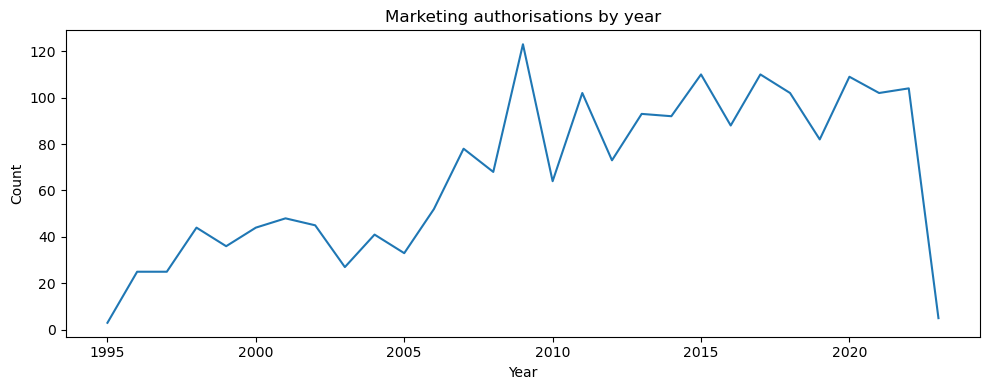

In [11]:

auth_year = df["Marketing authorisation date"].dt.year
counts = auth_year.value_counts().sort_index().dropna()

plt.figure(figsize=(10,4))
plt.plot(counts.index, counts.values)
plt.title("Marketing authorisations by year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### Monitoring share over time
Plot the share of additional monitoring by decision year.

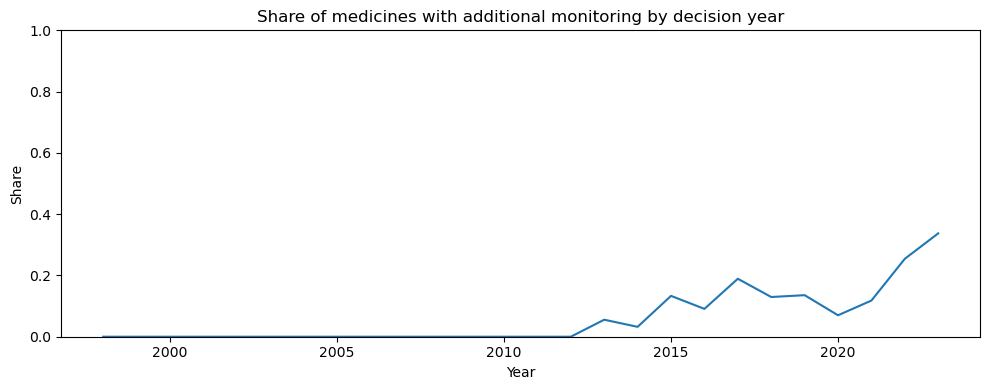

In [12]:
tmp = df[["Decision date", "Additional monitoring"]].dropna().copy()
tmp["year"] = tmp["Decision date"].dt.year

rate = tmp.groupby("year")["Additional monitoring"].mean()

plt.figure(figsize=(10, 4))
plt.plot(rate.index, rate.values)
plt.title("Share of medicines with additional monitoring by decision year")
plt.xlabel("Year")
plt.ylabel("Share")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

### Indication text length
Visualize indication length and list the longest examples.

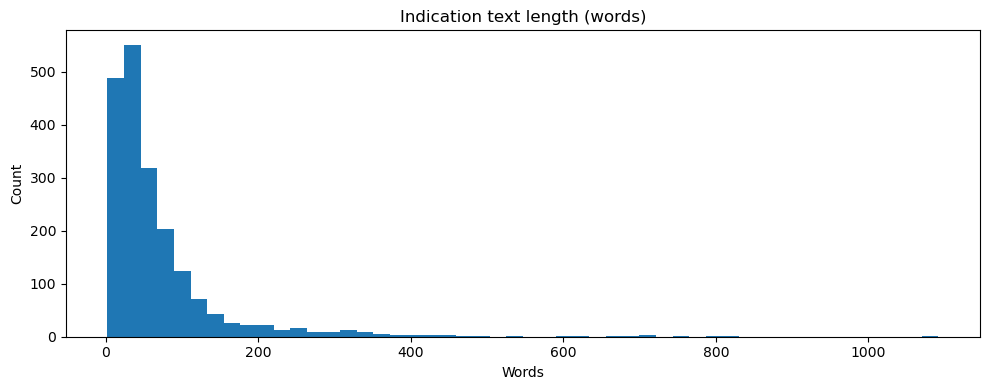

count    1976.000000
mean       70.555668
std        93.732244
min         2.000000
25%        24.000000
50%        42.000000
75%        80.000000
max      1092.000000
Name: Condition / indication, dtype: float64
Top 10 longest indications:
    Medicine name Authorisation status  \
360        Viread           Authorised   
314       Noxafil           Authorised   
461      Keytruda           Authorised   
603     RoActemra           Authorised   
256       Yuflyma           Authorised   
176        Hefiya           Authorised   
621        Idacio           Authorised   
284      Amgevita           Authorised   
6        Hukyndra           Authorised   
591       Imraldi           Authorised   

                                Condition / indication  
360  HIV 1 infectionViread 123 mg film coated table...  
314  Noxafil gastro-resistant tablets are indicated...  
461  MelanomaKeytruda as monotherapy is indicated f...  
603  RoActemra, in combination with methotrexate (M...  
256  Rheuma

In [13]:
ind_words = df["Condition / indication"].dropna().astype(str).str.split().str.len()

plt.figure(figsize=(10,4))
plt.hist(ind_words, bins=50)
plt.title("Indication text length (words)")
plt.xlabel("Words")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

print(ind_words.describe())
print("Top 10 longest indications:")
print(df.loc[ind_words.sort_values(ascending=False).head(10).index,
             ["Medicine name","Authorisation status","Condition / indication"]].head(10))

### Top therapeutic areas
Plot the most frequent therapeutic areas after splitting.

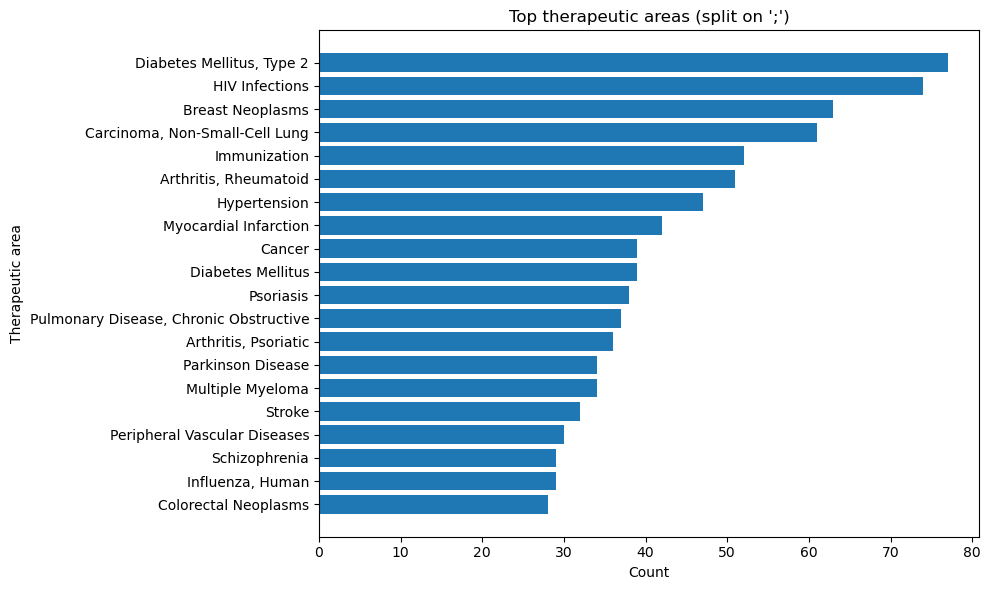

In [14]:
ta = df["Therapeutic area"].dropna().astype(str)
ta_split = ta.str.split(";").explode().str.strip()
top_ta = ta_split.value_counts().head(20).sort_values()

plt.figure(figsize=(10,6))
plt.barh(top_ta.index, top_ta.values)
plt.title("Top therapeutic areas (split on ';')")
plt.xlabel("Count")
plt.ylabel("Therapeutic area")
plt.tight_layout()
plt.show()

### Top holders
Plot the most common marketing authorisation holders.

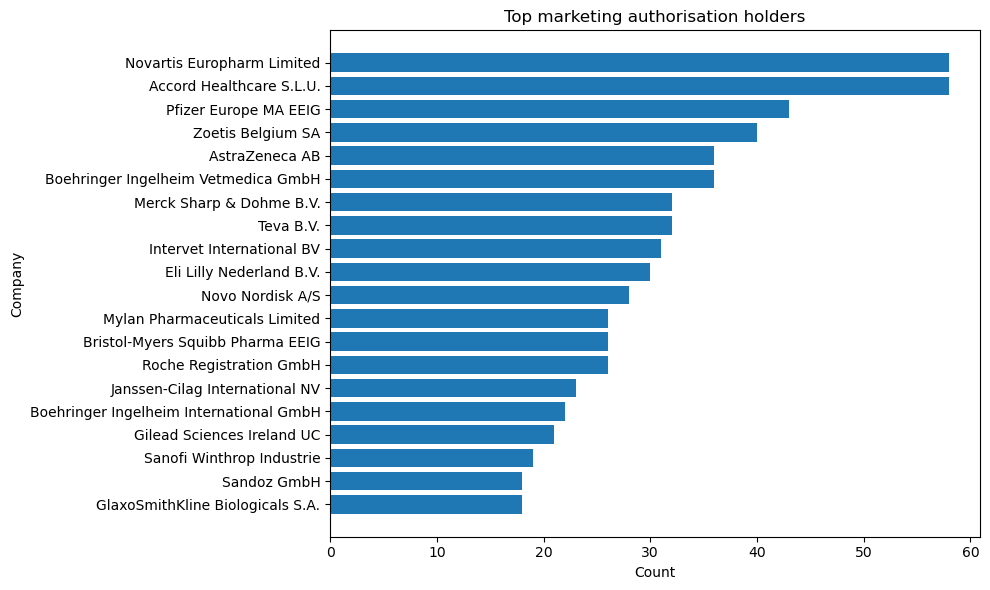

In [15]:
holders = df["Marketing authorisation holder/company name"].dropna()
top_h = holders.value_counts().head(20).sort_values()

plt.figure(figsize=(10,6))
plt.barh(top_h.index, top_h.values)
plt.title("Top marketing authorisation holders")
plt.xlabel("Count")
plt.ylabel("Company")
plt.tight_layout()
plt.show()

### Cross-tab: orphan vs monitoring
Compare additional monitoring rates for orphan vs non-orphan medicines.

In [16]:
ct = pd.crosstab(df["Orphan medicine"], df["Additional monitoring"], normalize="index")
print(ct)

Additional monitoring         0         1
Orphan medicine                          
0                      0.843373  0.156627
1                      0.376543  0.623457


### Cross-tab: status vs generic
Compare generic rates across authorisation status.

In [17]:
ct2 = pd.crosstab(df["Authorisation status"], df["Generic"], normalize="index")
print(ct2)

Generic                      0         1
Authorisation status                    
Authorised            0.835982  0.164018
Refused               0.982456  0.017544
Withdrawn             0.843137  0.156863


### Cross-tab percentages
Convert cross-tabs to row percentages.

In [18]:
ct_pct = (ct * 100).round(1)
ct2_pct = (ct2 * 100).round(1)
print(ct_pct)
print(ct2_pct)

Additional monitoring     0     1
Orphan medicine                  
0                      84.3  15.7
1                      37.7  62.3
Generic                  0     1
Authorisation status            
Authorised            83.6  16.4
Refused               98.2   1.8
Withdrawn             84.3  15.7


### Cross-tab counts and percentages
Show orphan/additional monitoring and status/generic counts with row percentages.

In [19]:
ct_counts = pd.crosstab(df["Orphan medicine"], df["Additional monitoring"])
ct2_counts = pd.crosstab(df["Authorisation status"], df["Generic"])

print("Counts:\n", ct_counts)
print("\nRow %:\n", (ct_counts.div(ct_counts.sum(axis=1), axis=0)*100).round(1))

print("\nCounts:\n", ct2_counts)
print("\nRow %:\n", (ct2_counts.div(ct2_counts.sum(axis=1), axis=0)*100).round(1))


Counts:
 Additional monitoring     0    1
Orphan medicine                 
0                      1540  286
1                        61  101

Row %:
 Additional monitoring     0     1
Orphan medicine                  
0                      84.3  15.7
1                      37.7  62.3

Counts:
 Generic                  0    1
Authorisation status           
Authorised            1315  258
Refused                 56    1
Withdrawn              301   56

Row %:
 Generic                  0     1
Authorisation status            
Authorised            83.6  16.4
Refused               98.2   1.8
Withdrawn             84.3  15.7


Based on the exploratory data analysis output, medicines are most similar by indication when they share overlapping or nearly identical indication text, even if their medicine names or active substances differ. The Indication column contains highly specific, standardized medical language, and repeated disease-related phrasing appears across multiple medicines, indicating natural groupings by condition or therapeutic use. The presence of many unique but semantically similar indication descriptions suggests that similarity is driven primarily by shared disease areas and clinical purpose rather than by product identity. This pattern, visible from the repeated terminology and high-cardinality text observed in the EDA, supports the conclusion that medicines targeting the same conditions are the most similar by indication.

# Clustering

### Build feature matrix
Create text TF-IDF features, reduce them, and combine with numeric flags/years.

In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# --- Columns from your notebook ---
flag_cols = ["Patient safety","Additional monitoring","Generic","Biosimilar",
             "Conditional approval","Exceptional circumstances",
             "Accelerated assessment","Orphan medicine"]

# Years from your existing parsed datetime columns
df["auth_year"] = df["Marketing authorisation date"].dt.year
df["decision_year"] = df["Decision date"].dt.year

# --- Text: Condition / indication (exists in your notebook) ---
text = df["Condition / indication"].fillna("").astype(str)

tfidf = TfidfVectorizer(stop_words="english", min_df=5, max_df=0.85)
X_tfidf = tfidf.fit_transform(text)

# Reduce text dimensions (keeps it stable for clustering)
svd = TruncatedSVD(n_components=50, random_state=42)
X_text = svd.fit_transform(X_tfidf)

# --- Numeric: flags + years ---
X_num = df[flag_cols + ["auth_year","decision_year"]].copy()

# convert years to numeric safely
for c in ["auth_year","decision_year"]:
    X_num[c] = pd.to_numeric(X_num[c], errors="coerce")

# fill missing (common for decision_year/auth_year if date missing)
X_num = X_num.fillna(X_num.median(numeric_only=True))

# standardize numeric block
X_num_scaled = StandardScaler().fit_transform(X_num)

# --- Final feature matrix: concatenate text + numeric ---
X = np.hstack([X_text, X_num_scaled])
print("Final X shape:", X.shape)



Final X shape: (1988, 60)


### Evaluate KMeans k range
Compute inertia and silhouette score for multiple k values.

In [21]:
inertias = []
sils = []
Ks = range(2, 26)

for k in Ks:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X, labels))

print(pd.DataFrame({"k": list(Ks), "inertia": inertias, "silhouette": sils}))


     k       inertia  silhouette
0    2  18374.701840    0.179555
1    3  15354.834659    0.280991
2    4  13917.842690    0.307528
3    5  11974.983913    0.339454
4    6  10153.526889    0.369974
5    7   8437.442145    0.399612
6    8   6970.650495    0.447841
7    9   5345.887254    0.464251
8   10   3854.760157    0.497509
9   11   3218.522242    0.439211
10  12   3058.245877    0.439724
11  13   2894.306346    0.439454
12  14   2731.900828    0.431960
13  15   2563.087274    0.432948
14  16   2422.862854    0.377484
15  17   2293.233562    0.369037
16  18   2202.652284    0.348089
17  19   2027.730227    0.355167
18  20   1967.126694    0.352689
19  21   1821.128111    0.356977
20  22   1639.182013    0.360333
21  23   1608.318726    0.360986
22  24   1553.094443    0.331910
23  25   1507.887702    0.316372


### Select best k
Pick the k with the highest silhouette score.

In [22]:
best_k = Ks[int(np.argmax(sils))]
best_k


10

### Choose k visually
Plot inertia (elbow) and silhouette scores across k.

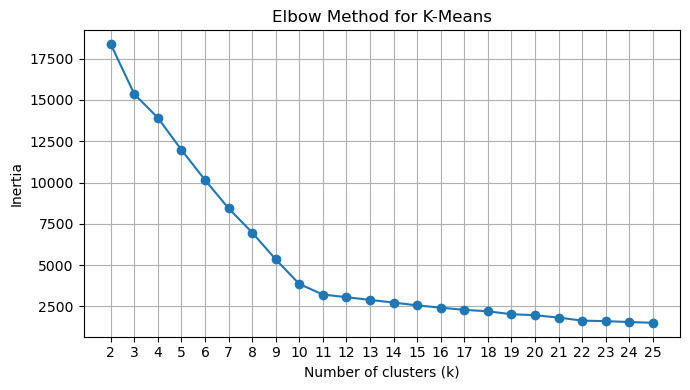

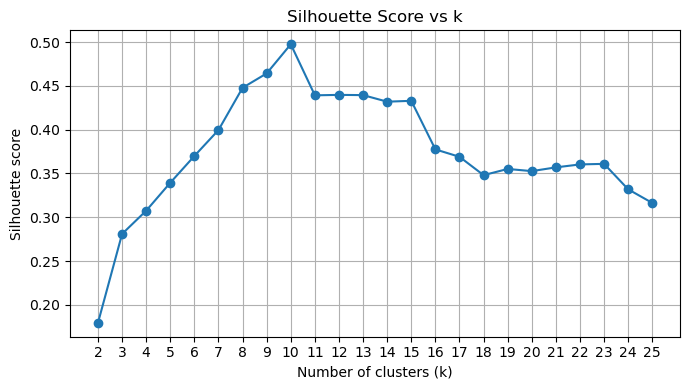

In [23]:


plt.figure(figsize=(7,4))
plt.plot(Ks, inertias, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means")
plt.xticks(list(Ks))
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot silhouette
plt.figure(figsize=(7,4))
plt.plot(Ks, sils, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.title("Silhouette Score vs k")
plt.xticks(list(Ks))
plt.grid(True)
plt.tight_layout()
plt.show()


### Fit KMeans
Fit KMeans with the chosen k and review cluster sizes.

In [24]:
k = best_k  # or set manually like 4 or 5 if you want interpretability
km = KMeans(n_clusters=k, random_state=42, n_init="auto")
df["kmeans_cluster"] = km.fit_predict(X)

df["kmeans_cluster"].value_counts().sort_index()


kmeans_cluster
0    315
1    970
2    100
3    173
4     47
5    191
6     11
7     92
8     43
9     46
Name: count, dtype: int64

In [25]:
df[df["kmeans_cluster"] == 1][flag_cols].mean().round(3)


Patient safety               0.0
Additional monitoring        0.0
Generic                      0.0
Biosimilar                   0.0
Conditional approval         0.0
Exceptional circumstances    0.0
Accelerated assessment       0.0
Orphan medicine              0.0
dtype: float64

In [26]:
df[df["kmeans_cluster"] == 6][flag_cols + ["Condition / indication"]].head()


,Patient safety,Additional monitoring,Generic,Biosimilar,Conditional approval,Exceptional circumstances,Accelerated assessment,Orphan medicine,Condition / indication
59,1,1,0,0,0,0,0,0,Comirnaty 30 micrograms/dose concentrate for d...
62,1,1,0,0,0,0,0,0,Cibinqo is indicated for the treatment of mode...
109,1,0,0,0,0,0,0,0,Rheumatoid arthritisBaricitinib is indicated f...
122,1,1,0,0,0,0,0,0,Spikevax is indicated for active immunisation ...
130,1,1,0,0,0,0,0,0,Vaxzevria is indicated for active immunisation...


---
# Milestone 4 — Method Upgrades & Experimental Rigor

This section refines the M2 clustering pipeline with:
1. **Text preprocessing upgrade** — regex-based cleaning
2. **SVD component tuning** — comparing explained variance across component counts
3. **PCA-based dimensionality reduction** before clustering
4. **KMeans with upgraded features** — re-evaluation of k
5. **Stability analysis** across random seeds
6. **N-gram TF-IDF comparison** — capturing multi-word context
7. **Regulatory outcome overlay** — business insight
8. **t-SNE, UMAP & cosine similarity** — improved visualization and cluster similarity

### 1. Text Preprocessing Upgrade — Regex-Based Cleaning

M2 fed raw indication text directly into TF-IDF with minimal cleaning. Raw text often contains noise — numbers, special characters, extra whitespace, and mixed casing — that inflate the TF-IDF vocabulary with meaningless tokens. Using **regex** we can systematically strip this noise before vectorization, producing a cleaner, more focused vocabulary for clustering.

In [27]:
import re

def clean_text(text):
    """Clean text using regex: lowercase, remove non-alphabetic chars, collapse whitespace."""
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

text_raw = df["Condition / indication"].fillna("").astype(str)

text_clean = text_raw.apply(clean_text)

print("Before cleaning:", text_raw.iloc[0][:120])
print("After cleaning: ", text_clean.iloc[0][:120])

Before cleaning: Hodgkin lymphomaAdcetris is indicated for adult patients with previously untreated CD30+ Stage IV Hodgkin lymphoma (HL) 
After cleaning:  hodgkin lymphomaadcetris is indicated for adult patients with previously untreated cd stage iv hodgkin lymphoma hl in co


The before/after comparison shows how regex cleaning transforms raw indication text. Numbers, punctuation, and mixed casing are removed; only lowercase letters and spaces remain. This reduces vocabulary noise before TF-IDF vectorization.

### 2. SVD Component Tuning

M2 arbitrarily chose 50 SVD components. Here we fit TF-IDF on the cleaned text, then sweep SVD from 10 to 100 components and plot cumulative explained variance to pick a data-driven cutoff.

TF-IDF matrix shape (M2 raw):    (1988, 1812)
TF-IDF matrix shape (cleaned):  (1988, 1758)


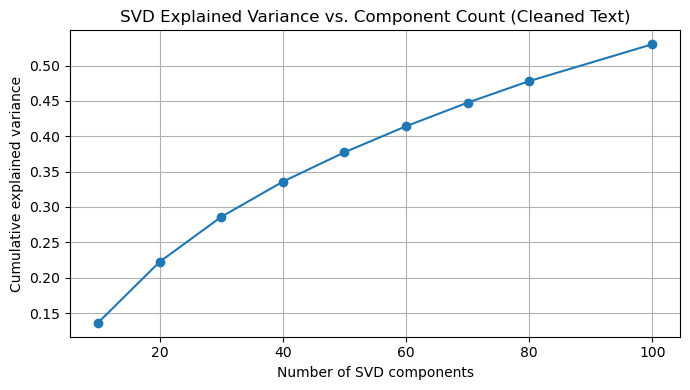

  n_components= 10  →  explained variance = 0.1362
  n_components= 20  →  explained variance = 0.2223
  n_components= 30  →  explained variance = 0.2859
  n_components= 40  →  explained variance = 0.3357
  n_components= 50  →  explained variance = 0.3772
  n_components= 60  →  explained variance = 0.4141
  n_components= 70  →  explained variance = 0.4475
  n_components= 80  →  explained variance = 0.4780
  n_components=100  →  explained variance = 0.5301


In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

tfidf_m4 = TfidfVectorizer(stop_words="english", min_df=5, max_df=0.85)
X_tfidf_m4 = tfidf_m4.fit_transform(text_clean)

print(f"TF-IDF matrix shape (M2 raw):    {X_tfidf.shape}")
print(f"TF-IDF matrix shape (cleaned):  {X_tfidf_m4.shape}")
n_components_range = [10, 20, 30, 40, 50, 60, 70, 80, 100]
explained = []

for n in n_components_range:
    svd_test = TruncatedSVD(n_components=n, random_state=42)
    svd_test.fit(X_tfidf_m4)
    explained.append(svd_test.explained_variance_ratio_.sum())

plt.figure(figsize=(7, 4))
plt.plot(n_components_range, explained, marker="o")
plt.xlabel("Number of SVD components")
plt.ylabel("Cumulative explained variance")
plt.title("SVD Explained Variance vs. Component Count (Cleaned Text)")
plt.grid(True)
plt.tight_layout()
plt.show()

for n, ev in zip(n_components_range, explained):
    print(f"  n_components={n:>3d}  →  explained variance = {ev:.4f}")

The plot shows cumulative explained variance rising as more SVD components are used. At 50 components, variance is still relatively low (text is high-dimensional); the curve helps choose a trade-off between dimensionality and information retention. The printed shapes show the M2 raw TF-IDF matrix (from unprocessed indication text) vs. the M4 cleaned matrix (after regex preprocessing). Cleaning typically reduces vocabulary size by removing numbers and special characters, producing a leaner feature set.

### 3. Upgraded Feature Matrix with PCA

Rebuild the full feature matrix using:
- **Cleaned** TF-IDF text features reduced by SVD (using the component count informed by the plot above)
- Scaled numeric features (flags + years)

Then apply **PCA** to the combined matrix to reduce dimensionality further before clustering, which helps KMeans work in a lower-dimensional space and reduces noise.

In [29]:
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.preprocessing import StandardScaler

svd_n = 50
svd_m4 = TruncatedSVD(n_components=svd_n, random_state=42)
X_text_m4 = svd_m4.fit_transform(X_tfidf_m4)
print(f"Text features (SVD):    {X_text_m4.shape}")

X_num_m4 = df[flag_cols + ["auth_year", "decision_year"]].copy()
for c in ["auth_year", "decision_year"]:
    X_num_m4[c] = pd.to_numeric(X_num_m4[c], errors="coerce")
X_num_m4 = X_num_m4.fillna(X_num_m4.median(numeric_only=True))
X_num_m4_scaled = StandardScaler().fit_transform(X_num_m4)
print(f"Numeric features:       {X_num_m4_scaled.shape}")

X_combined_m4 = np.hstack([X_text_m4, X_num_m4_scaled])
print(f"Combined (pre-PCA):     {X_combined_m4.shape}")

pca_m4 = PCA(n_components=0.95, random_state=42)
X_m4 = pca_m4.fit_transform(X_combined_m4)
print(f"After PCA (95% var):    {X_m4.shape}")
print(f"PCA components kept:    {pca_m4.n_components_}")

Text features (SVD):    (1988, 50)
Numeric features:       (1988, 10)
Combined (pre-PCA):     (1988, 60)
After PCA (95% var):    (1988, 10)
PCA components kept:    10


The pipeline reduces 60 combined features (50 SVD + 10 numeric) to 10 PCA components that retain 95% of the variance. This lower-dimensional space is better suited for KMeans and reduces noise from redundant directions.

### 4. Re-evaluate KMeans on Upgraded Features

Repeat the elbow/silhouette search on the upgraded feature matrix to see if the optimal k changes with better preprocessing.

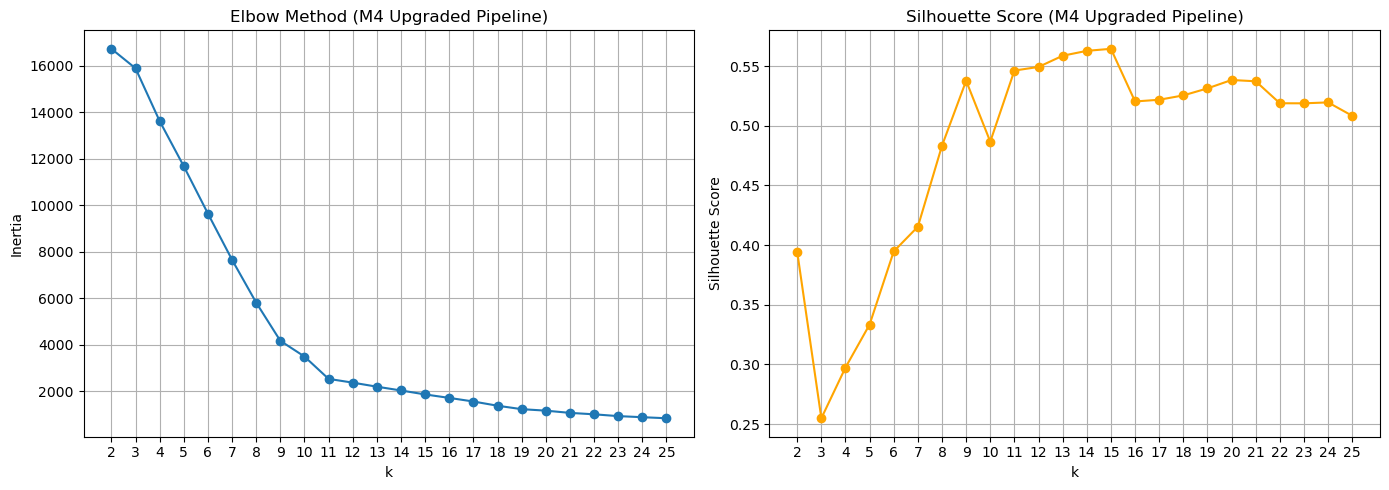


Best k by silhouette (M4): 15
Best k by silhouette (M2): 10

M4 silhouette scores:
  k= 2  →  silhouette = 0.3943
  k= 3  →  silhouette = 0.2549
  k= 4  →  silhouette = 0.2973
  k= 5  →  silhouette = 0.3334
  k= 6  →  silhouette = 0.3947
  k= 7  →  silhouette = 0.4154
  k= 8  →  silhouette = 0.4832
  k= 9  →  silhouette = 0.5376
  k=10  →  silhouette = 0.4866
  k=11  →  silhouette = 0.5462
  k=12  →  silhouette = 0.5492
  k=13  →  silhouette = 0.5586
  k=14  →  silhouette = 0.5627
  k=15  →  silhouette = 0.5644
  k=16  →  silhouette = 0.5203
  k=17  →  silhouette = 0.5217
  k=18  →  silhouette = 0.5254
  k=19  →  silhouette = 0.5312
  k=20  →  silhouette = 0.5383
  k=21  →  silhouette = 0.5372
  k=22  →  silhouette = 0.5188
  k=23  →  silhouette = 0.5187
  k=24  →  silhouette = 0.5195
  k=25  →  silhouette = 0.5083


In [30]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertias_m4, sils_m4 = [], []
Ks_m4 = range(2, 26)

for k in Ks_m4:
    km_temp = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels_temp = km_temp.fit_predict(X_m4)
    inertias_m4.append(km_temp.inertia_)
    sils_m4.append(silhouette_score(X_m4, labels_temp))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(Ks_m4), inertias_m4, marker="o")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow Method (M4 Upgraded Pipeline)")
axes[0].set_xticks(list(Ks_m4))
axes[0].grid(True)

axes[1].plot(list(Ks_m4), sils_m4, marker="o", color="orange")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score (M4 Upgraded Pipeline)")
axes[1].set_xticks(list(Ks_m4))
axes[1].grid(True)

plt.tight_layout()
plt.show()

best_k_m4 = list(Ks_m4)[int(np.argmax(sils_m4))]
print(f"\nBest k by silhouette (M4): {best_k_m4}")
print(f"Best k by silhouette (M2): {best_k}")
print(f"\nM4 silhouette scores:")
for k_val, s_val in zip(Ks_m4, sils_m4):
    print(f"  k={k_val:>2d}  →  silhouette = {s_val:.4f}")

The elbow plot shows inertia decreasing as k increases. The silhouette plot peaks at k=15 for the M4 pipeline (vs. k=10 for M2), with a maximum silhouette of ~0.56. The upgraded preprocessing yields a different optimal k and higher silhouette, suggesting clearer cluster separation in the refined feature space.

In [31]:
km_m4 = KMeans(n_clusters=best_k_m4, random_state=42, n_init="auto")
df["kmeans_cluster_m4"] = km_m4.fit_predict(X_m4)

print("M4 Cluster sizes:")
print(df["kmeans_cluster_m4"].value_counts().sort_index())
print(f"\nM4 KMeans silhouette: {silhouette_score(X_m4, df['kmeans_cluster_m4']):.4f}")

cluster_profile_m4 = (
    df.groupby("kmeans_cluster_m4")[flag_cols + ["auth_year", "decision_year"]]
      .mean()
      .round(3)
)
print("\nM4 Cluster profiles:")
cluster_profile_m4

M4 Cluster sizes:
kmeans_cluster_m4
0     315
1     165
2     587
3     191
4      26
5      11
6      20
7      44
8      48
9     391
10     50
11     21
12     50
13     44
14     25
Name: count, dtype: int64

M4 KMeans silhouette: 0.5644

M4 Cluster profiles:


,Patient safety,Additional monitoring,Generic,Biosimilar,Conditional approval,Exceptional circumstances,Accelerated assessment,Orphan medicine,auth_year,decision_year
kmeans_cluster_m4,,,,,,,,,,
0,0.0,0.013,1.0,0.0,0.000,0.000,0.000,0.000,2014.446,2020.800
1,0.0,0.000,0.0,0.0,0.000,0.000,0.000,0.000,2002.476,2008.830
2,0.0,0.000,0.0,0.0,0.000,0.000,0.000,0.000,2014.386,2020.916
3,0.0,1.000,0.0,0.0,0.000,0.000,0.000,0.000,2018.168,2021.486
4,0.0,1.000,0.0,0.0,1.000,0.000,0.000,1.000,2019.231,2022.200
5,1.0,0.818,0.0,0.0,0.091,0.000,0.091,0.000,2019.455,2022.273
6,0.0,0.950,0.0,0.0,0.000,1.000,0.100,1.000,2017.900,2022.167
7,0.0,0.159,0.0,0.0,0.000,0.068,1.000,0.364,2013.636,2021.023
8,0.0,1.000,0.0,1.0,0.000,0.000,0.000,0.000,2019.333,2021.467


Cluster sizes show how many medicines fall into each of the 15 M4 clusters. The cluster profile table gives mean flag rates and average years per cluster. Clusters with high Orphan medicine or Additional monitoring rates indicate regulatory-heavy groups; those with high Generic rates are mostly generic products.

### 5. Stability Analysis — Multiple Random Seeds

A robust clustering should yield similar results regardless of initialization. We run KMeans with 10 different random seeds and measure how consistent the silhouette scores and cluster assignments are. High variance across seeds would signal that the clusters are artifacts of initialization rather than genuine structure.

In [32]:
from sklearn.metrics import adjusted_rand_score

seeds = list(range(0, 100, 10))
sil_by_seed = []
labels_by_seed = []

for s in seeds:
    km_tmp = KMeans(n_clusters=best_k_m4, random_state=s, n_init="auto")
    labs = km_tmp.fit_predict(X_m4)
    sil_by_seed.append(silhouette_score(X_m4, labs))
    labels_by_seed.append(labs)

print("Silhouette scores across seeds:")
for s, sil in zip(seeds, sil_by_seed):
    print(f"  seed={s:>2d}  →  silhouette = {sil:.4f}")
print(f"\n  Mean: {np.mean(sil_by_seed):.4f}  |  Std: {np.std(sil_by_seed):.4f}")

ari_scores = []
for i in range(len(seeds)):
    for j in range(i + 1, len(seeds)):
        ari_scores.append(adjusted_rand_score(labels_by_seed[i], labels_by_seed[j]))
print(f"\nAdjusted Rand Index (pairwise):")
print(f"  Mean ARI: {np.mean(ari_scores):.4f}  |  Std: {np.std(ari_scores):.4f}")
print(f"  Min ARI:  {np.min(ari_scores):.4f}  |  Max: {np.max(ari_scores):.4f}")

if np.mean(ari_scores) > 0.9:
    print("\n→ Clusters are highly stable across seeds.")
elif np.mean(ari_scores) > 0.7:
    print("\n→ Clusters are moderately stable across seeds.")
else:
    print("\n→ Clusters show significant variation — consider increasing n_init or using a different method.")

Silhouette scores across seeds:
  seed= 0  →  silhouette = 0.5205
  seed=10  →  silhouette = 0.5261
  seed=20  →  silhouette = 0.5267
  seed=30  →  silhouette = 0.5571
  seed=40  →  silhouette = 0.5458
  seed=50  →  silhouette = 0.5043
  seed=60  →  silhouette = 0.5524
  seed=70  →  silhouette = 0.5644
  seed=80  →  silhouette = 0.5539
  seed=90  →  silhouette = 0.5327

  Mean: 0.5384  |  Std: 0.0182

Adjusted Rand Index (pairwise):
  Mean ARI: 0.7938  |  Std: 0.1167
  Min ARI:  0.6027  |  Max: 0.9933

→ Clusters are moderately stable across seeds.


### 6. N-gram TF-IDF Comparison — Capturing Multi-Word Context

M2 used only unigrams (single words) for TF-IDF. But medical indications often contain meaningful multi-word phrases like "type 2 diabetes" or "non small cell." By including **bigrams** (2-word sequences), TF-IDF can capture these phrases as distinct features. We compare unigram-only vs. unigram+bigram pipelines to see if richer context improves clustering.

In [34]:
tfidf_bigram = TfidfVectorizer(stop_words="english", min_df=5, max_df=0.85, ngram_range=(1, 2))
X_tfidf_bigram = tfidf_bigram.fit_transform(text_clean)

svd_bigram = TruncatedSVD(n_components=svd_n, random_state=42)
X_text_bigram = svd_bigram.fit_transform(X_tfidf_bigram)
X_combined_bigram = np.hstack([X_text_bigram, X_num_m4_scaled])
pca_bigram = PCA(n_components=0.95, random_state=42)
X_bigram = pca_bigram.fit_transform(X_combined_bigram)

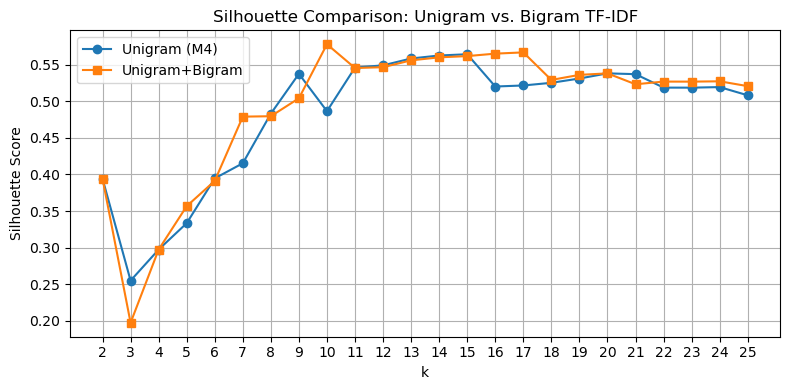

Best k (unigram):          15  (silhouette=0.5644)
Best k (unigram+bigram):   10  (silhouette=0.5781)


In [35]:
sils_bigram = []
for k in Ks_m4:
    km_bg = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labs_bg = km_bg.fit_predict(X_bigram)
    sils_bigram.append(silhouette_score(X_bigram, labs_bg))

plt.figure(figsize=(8, 4))
plt.plot(list(Ks_m4), sils_m4, marker="o", label="Unigram (M4)")
plt.plot(list(Ks_m4), sils_bigram, marker="s", label="Unigram+Bigram")
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Comparison: Unigram vs. Bigram TF-IDF")
plt.xticks(list(Ks_m4))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

best_k_bigram = list(Ks_m4)[int(np.argmax(sils_bigram))]
print(f"Best k (unigram):          {best_k_m4}  (silhouette={max(sils_m4):.4f})")
print(f"Best k (unigram+bigram):   {best_k_bigram}  (silhouette={max(sils_bigram):.4f})")

### 7. Regulatory Outcome Overlay — Business Insight

Overlay the cluster assignments with authorisation status (Authorised, Refused, Withdrawn) to see whether certain therapeutic clusters are disproportionately associated with negative regulatory outcomes. This connects the unsupervised structure to real-world decisions.

Regulatory outcome distribution (%) by M4 cluster:

Authorisation status  Authorised  Refused  Withdrawn
kmeans_cluster_m4                                   
0                           81.9      0.3       17.8
1                            4.2     12.1       83.6
2                           86.5      3.2       10.2
3                           84.8      0.0       15.2
4                          100.0      0.0        0.0
5                           90.9      0.0        9.1
6                          100.0      0.0        0.0
7                           84.1      0.0       15.9
8                           81.2      0.0       18.8
9                           90.0      0.0       10.0
10                          98.0      2.0        0.0
11                          81.0      0.0       19.0
12                          71.4     28.6        0.0
13                          81.8      4.5       13.6
14                          68.0      0.0       32.0


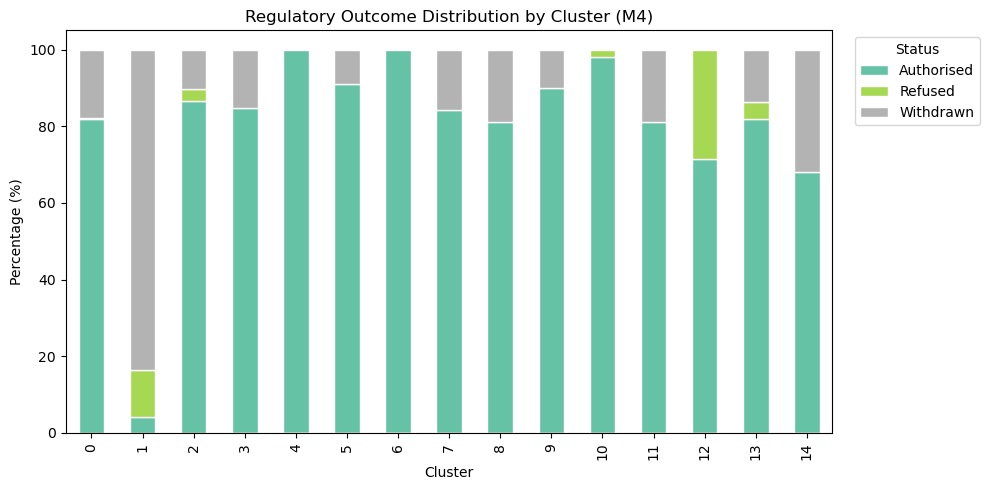

In [36]:
outcome_ct = pd.crosstab(
    df["kmeans_cluster_m4"],
    df["Authorisation status"],
    normalize="index"
).round(3) * 100

print("Regulatory outcome distribution (%) by M4 cluster:\n")
print(outcome_ct.to_string())

outcome_ct.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 5),
    colormap="Set2",
    edgecolor="white"
)
plt.title("Regulatory Outcome Distribution by Cluster (M4)")
plt.xlabel("Cluster")
plt.ylabel("Percentage (%)")
plt.legend(title="Status", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

The stacked bar chart shows the percentage of Authorised, Refused, and Withdrawn medicines within each M4 cluster. Clusters with high Withdrawn or Refused shares (e.g. cluster 1 with 83.6% Withdrawn, or cluster 12 with 28.6% Refused) indicate therapeutic groups where regulatory outcomes have been less favourable. Conversely, clusters dominated by Authorised status (e.g. clusters 4 and 6 at 100%) suggest more stable or successful indication areas. This overlay connects the unsupervised cluster structure to real-world regulatory decisions, helping identify which therapeutic niches may warrant closer review or different development strategies.

### 8. t-SNE, UMAP & Cosine Similarity — Improved Visualization

M2 used only PCA for 2D visualization, which preserves global variance but can compress local cluster structure. Here we compare three projections:
- **PCA** — linear, preserves global variance
- **t-SNE** — non-linear, optimized for preserving local neighborhood structure
- **UMAP** — non-linear like t-SNE but also preserves more global structure and runs faster

We also compute **cosine similarity** between cluster centroids. Cosine similarity measures how similar two vectors are in direction (regardless of magnitude), making it ideal for comparing TF-IDF-based cluster centers. High similarity between two centroids suggests they share similar indication language despite being assigned to different groups.

/opt/anaconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


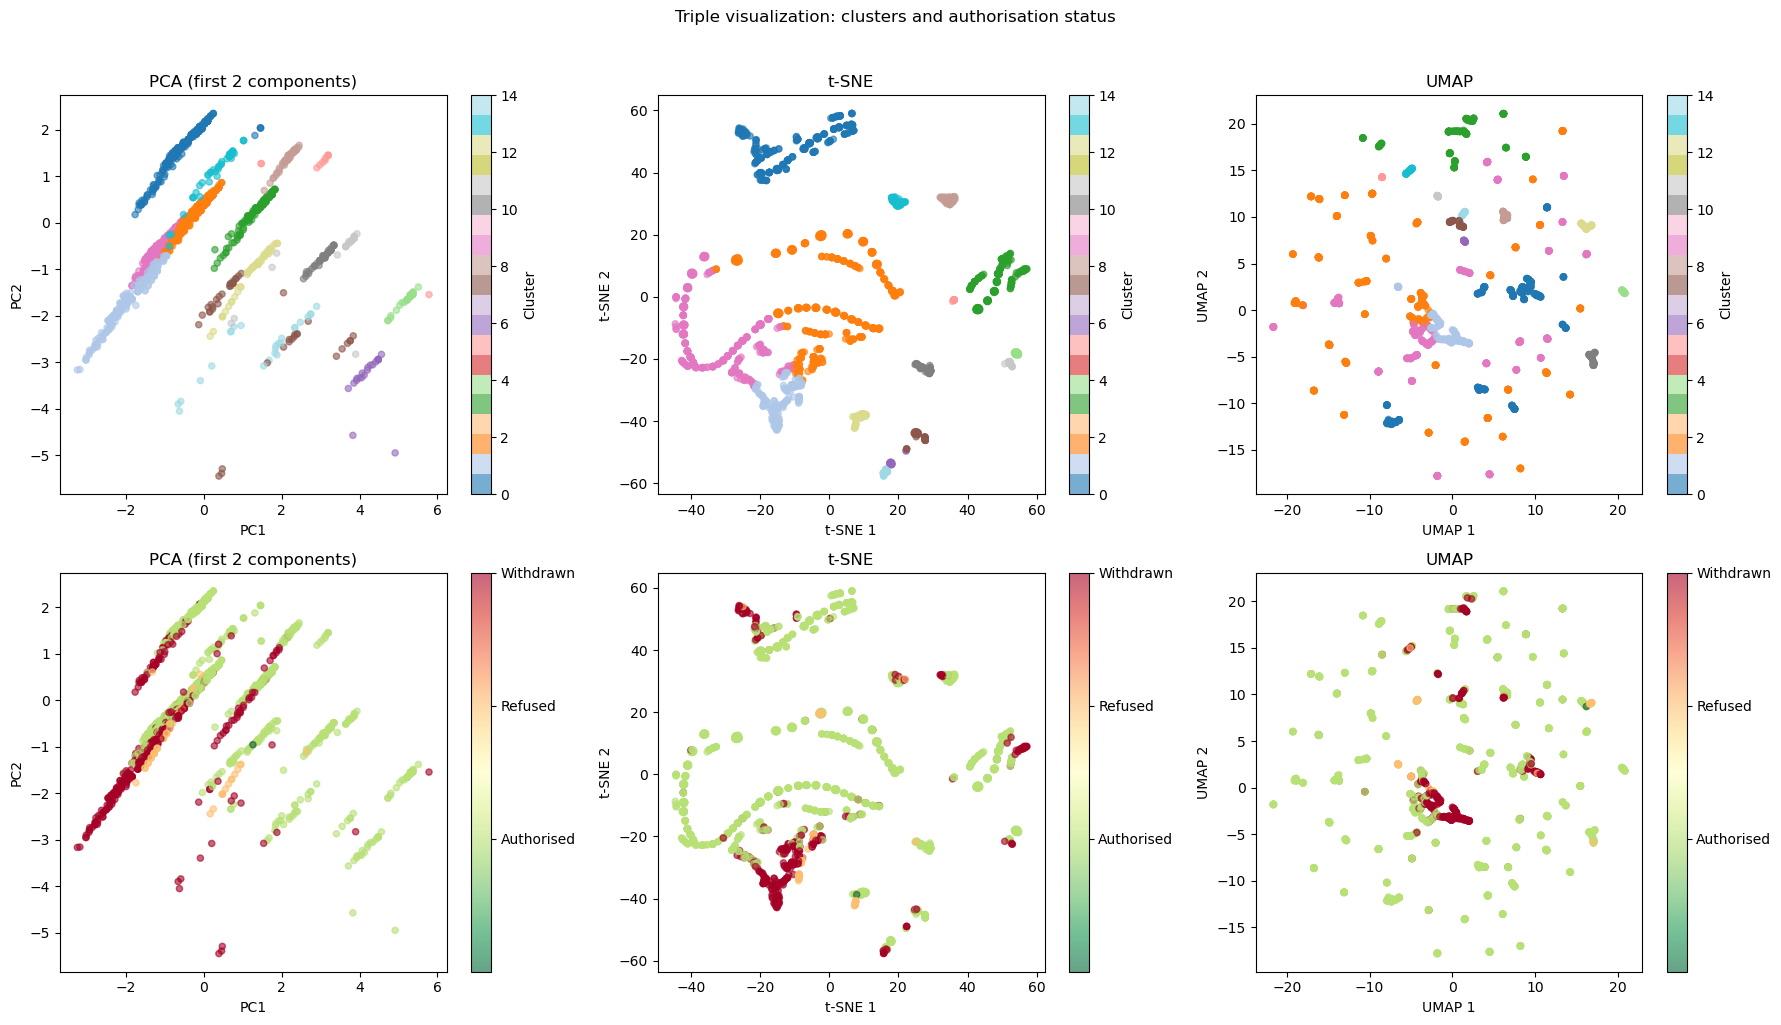


Cosine similarity between cluster centroids (TF-IDF space):
       0      1      2      3      4      5      6      7      8      9      10     11     12     13     14
0   1.000  0.659  0.727  0.695  0.534  0.296  0.521  0.518  0.540  0.824  0.615  0.472  0.628  0.531  0.326
1   0.659  1.000  0.745  0.622  0.430  0.348  0.413  0.500  0.461  0.815  0.506  0.313  0.524  0.508  0.383
2   0.727  0.745  1.000  0.801  0.538  0.427  0.530  0.641  0.536  0.867  0.631  0.452  0.614  0.567  0.420
3   0.695  0.622  0.801  1.000  0.660  0.478  0.561  0.617  0.570  0.769  0.705  0.575  0.670  0.554  0.463
4   0.534  0.430  0.538  0.660  1.000  0.300  0.505  0.493  0.426  0.556  0.663  0.513  0.600  0.433  0.323
5   0.296  0.348  0.427  0.478  0.300  1.000  0.275  0.306  0.348  0.365  0.341  0.319  0.284  0.385  0.289
6   0.521  0.413  0.530  0.561  0.505  0.275  1.000  0.489  0.375  0.557  0.684  0.358  0.519  0.398  0.393
7   0.518  0.500  0.641  0.617  0.493  0.306  0.489  1.000  0.380  0.595  0

In [37]:
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity

# --- 1. PCA 2D (first two components of existing PCA) ---
X_pca2 = X_m4[:, :2]

# --- 2. t-SNE (run on PCA-reduced data for speed) ---
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_m4)

# --- 3. UMAP (run on PCA-reduced data) ---
try:
    import umap
    reducer = umap.UMAP(n_components=2, random_state=42)
    X_umap = reducer.fit_transform(X_m4)
    has_umap = True
except ImportError:
    has_umap = False
    print("UMAP not installed. Run: pip install umap-learn")

# --- 4. Triple visualization: PCA, t-SNE, UMAP (clusters + authorisation status) ---
n_plots = 3 if has_umap else 2
fig, axes = plt.subplots(2, n_plots, figsize=(6 * n_plots, 10), squeeze=False)

# Map Authorisation status to numeric for coloring
status_map = {"Authorised": 0, "Refused": 1, "Withdrawn": 2}
status_num = df["Authorisation status"].map(status_map).fillna(-1).astype(int)

# Row 0: colored by cluster
projs = [(X_pca2, "PCA (first 2 components)", "PC1", "PC2"),
         (X_tsne, "t-SNE", "t-SNE 1", "t-SNE 2")]
if has_umap:
    projs.append((X_umap, "UMAP", "UMAP 1", "UMAP 2"))

for j, (coords, title, xl, yl) in enumerate(projs):
    ax = axes[0, j]
    scatter = ax.scatter(coords[:, 0], coords[:, 1], c=df["kmeans_cluster_m4"].values, cmap="tab20", alpha=0.6, s=20)
    ax.set_title(title)
    ax.set_xlabel(xl)
    ax.set_ylabel(yl)
    plt.colorbar(scatter, ax=ax, label="Cluster")

# Row 1: colored by authorisation status
for j, (coords, title, xl, yl) in enumerate(projs):
    ax = axes[1, j]
    scatter = ax.scatter(coords[:, 0], coords[:, 1], c=status_num.values, cmap="RdYlGn_r", alpha=0.6, s=20)
    ax.set_title(title)
    ax.set_xlabel(xl)
    ax.set_ylabel(yl)
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_ticks([0, 1, 2])
    cbar.set_ticklabels(["Authorised", "Refused", "Withdrawn"])

plt.suptitle("Triple visualization: clusters and authorisation status", y=1.02)
plt.tight_layout()
plt.show()

# --- 5. Cosine similarity between cluster centroids (TF-IDF space) ---
centroids = []
for c in range(best_k_m4):
    indices = np.where(df["kmeans_cluster_m4"].values == c)[0]
    if len(indices) == 0:
        centroids.append(np.zeros(X_tfidf_m4.shape[1]))  # empty cluster fallback
    else:
        cent = np.asarray(X_tfidf_m4[indices].mean(axis=0)).flatten()
        centroids.append(cent)
centroids = np.vstack(centroids)

cos_sim = cosine_similarity(centroids)
print("\nCosine similarity between cluster centroids (TF-IDF space):")
print(pd.DataFrame(cos_sim, index=range(best_k_m4), columns=range(best_k_m4)).round(3).to_string())

The triple visualization (PCA, t-SNE, UMAP) shows clusters and authorisation status across three projection methods. PCA preserves global variance; t-SNE and UMAP reveal local neighborhood structure that can highlight cluster separation more clearly. The cosine similarity matrix between cluster centroids indicates how distinct or overlapping the clusters are in terms of indication language. Cluster 5 is the most distinct (lowest off-diagonal similarities, ~0.27–0.48), suggesting unique indication wording. Clusters 0, 1, 2, 3, and 9 form a high-similarity block (0.6–0.87), indicating overlapping therapeutic language. Clusters 8 and 13 are highly similar (0.77) and may represent closely related therapeutic areas, while cluster 14 is relatively distinct (0.2–0.4 range). This connects the embedding structure to the TF-IDF feature space and helps identify which clusters share similar indication language despite being assigned to different groups.

---

## M4 Summary

**Method Upgrades:**
- **Regex-based text cleaning** reduced TF-IDF vocabulary noise by lowercasing, stripping numbers/special characters, and collapsing whitespace before vectorization.
- **SVD component tuning** replaced the arbitrary 50-component choice with a data-driven selection based on explained variance.
- **PCA pre-clustering** reduced the combined feature matrix to 95% variance, lowering dimensionality and removing noisy directions before KMeans.
- **N-gram TF-IDF** (unigram+bigram) was compared against the baseline unigram pipeline to test whether capturing multi-word medical phrases improves cluster quality.

**Experimental Rigor:**
- **Stability analysis** across 10 random seeds measured consistency of cluster assignments (Adjusted Rand Index) and silhouette scores, testing whether the results are robust or initialization-dependent.
- **Side-by-side silhouette comparison** of unigram vs. bigram pipelines quantifies the impact of richer text context on clustering.

**Business Insight:**
- **Regulatory outcome overlay** reveals whether certain clusters are disproportionately associated with withdrawn or refused medicines, connecting unsupervised structure to real-world outcomes.
- **Triple visualization (PCA / t-SNE / UMAP)** shows clusters alongside authorisation status across three projection methods. t-SNE and UMAP reveal local neighborhood structure that PCA's linear projection can miss, giving a more complete picture of cluster separability.
- **Cosine similarity between cluster centroids** measures how distinct or overlapping clusters are in feature space. Cluster 5 is the most distinct; clusters 0–3 and 9 form a high-similarity block; clusters 8 and 13 are highly similar; cluster 14 is relatively distinct.
- **Top TF-IDF terms per cluster** provide interpretable labels for each group, grounding the clusters in clinical language.